<a href="https://colab.research.google.com/github/FinaNurilAulia/road-detection1/blob/main/road_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Hello, Lane Detection!")

Hello, Lane Detection!


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir("/content/drive/MyDrive"))

['4C Fina Nuril Aulia Diagram Use Case Aplikasi Mango Mart .pdf', 'KTI FINA NURIL AULIA XII MIA 2.pdf', 'PROJECT FINA NURIL AULIA XII MIA 2.rar', '16367070688902875633956921042807.jpg', '16367071051928434766442480751585.jpg', 'Kelengkapan span ptkin', 'Screenshot_20220807-080651_Gallery (1).jpg', 'Screenshot_20220807-080948_Gallery.jpg', 'Screenshot_20220807-080651_Gallery.jpg', 'Screenshot_20220808-164051_Chrome.jpg', 'MATERI 1 FINA NURIL AULIA KELOMPOK 11 T.MTK.pdf', 'MATERI 2 FINA NURIL AULIA KELOMPOK 11 T MTK.pdf', 'MATERI 3 FINA NURIL AULIA.pdf', 'MATERI 4 FINA.pdf', 'MATERI 5 FINA NURIL AULIA.pdf', 'Fina', 'Daftar uyp', 'Classroom', 'TUGAS SISFO WHATSAPP.drawio', 'DFD WHATSAPP KELOMPOK 4.pdf', 'nilai 1.gsheet', 'Students Social Media Addiction.gsheet', 'LAPORAN PROYEK AKHIR FINA NURIL AULIA (2).docx', 'LAPORAN PROYEK AKHIR FINA NURIL AULIA (1).gdoc', 'LAPORAN PROYEK AKHIR FINA NURIL AULIA.gdoc', 'Formulir tanpa judul.gform', 'Respon Proyek Sistem Manajemen Sederhana untuk UMKM.gs

In [3]:
print(os.listdir("/content/drive/MyDrive/road-detection1"))

['jalan.jpeg']


In [7]:
import cv2

IMAGE_PATH = "/content/drive/MyDrive/road-detection1/jalan.jpeg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    print("❌ Gambar tidak dapat dibuka")
else:
    print("✅ Gambar berhasil dibuka")
    print("Ukuran gambar:", image.shape)

✅ Gambar berhasil dibuka
Ukuran gambar: (928, 1600, 3)


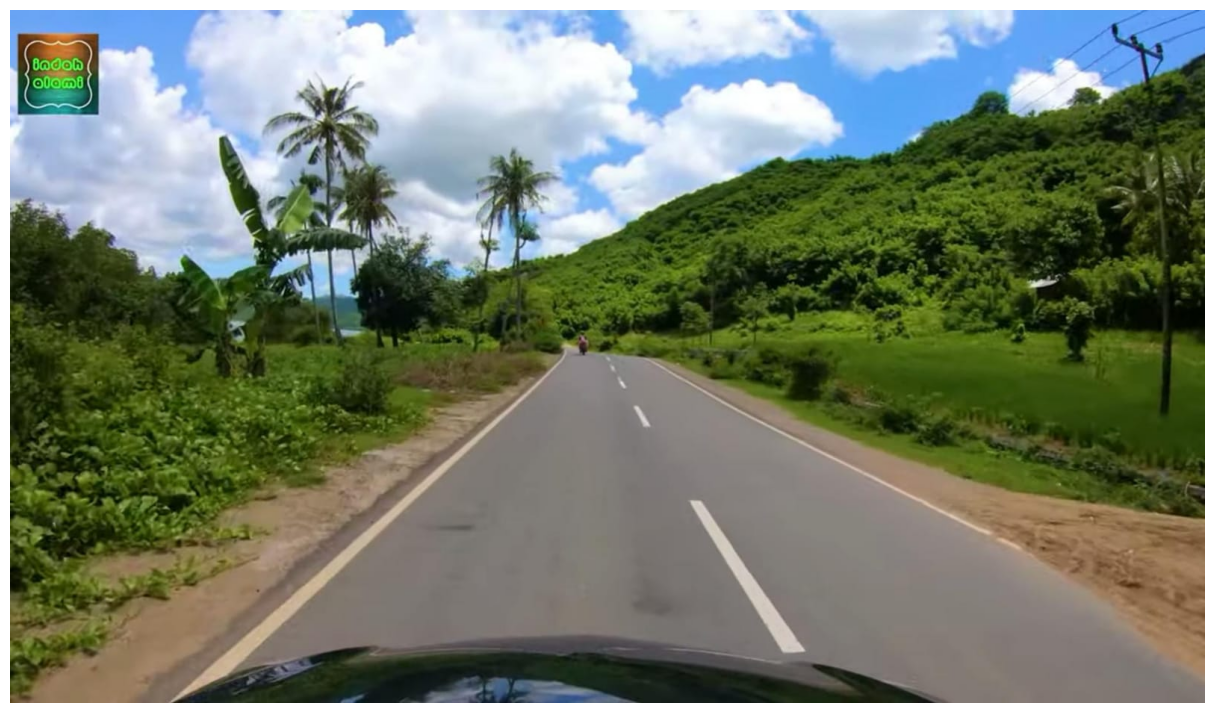

In [9]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 9))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

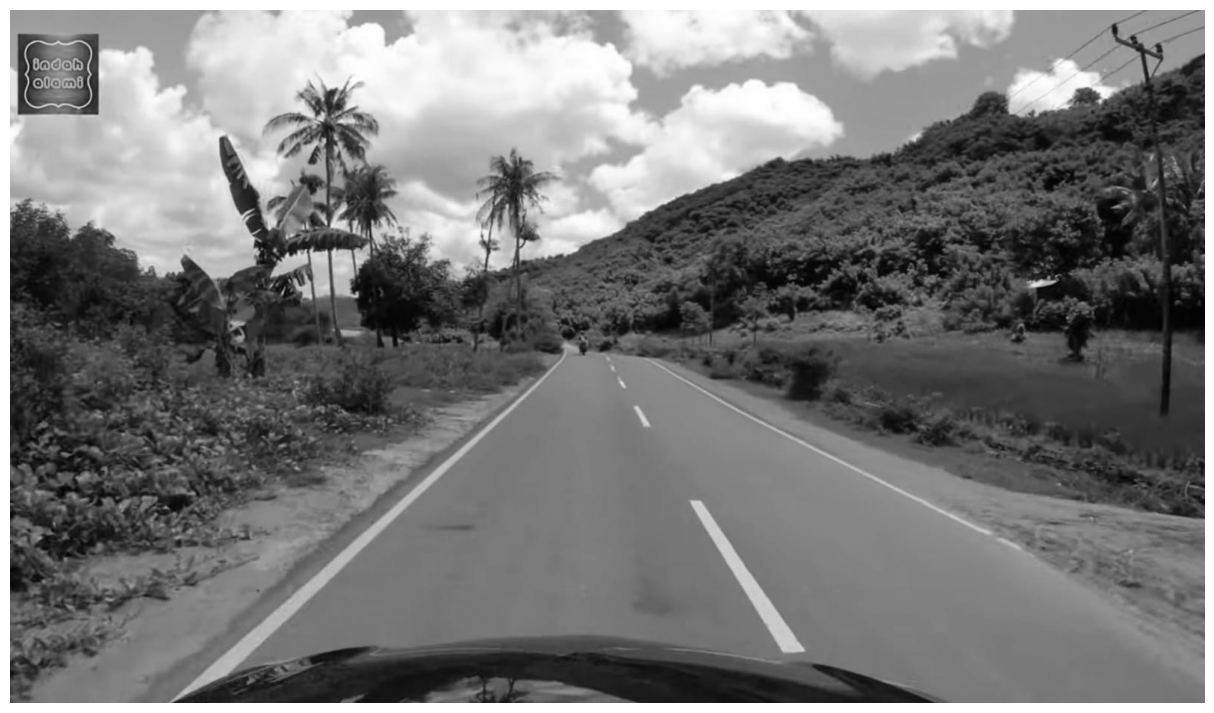

In [10]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(16, 9))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

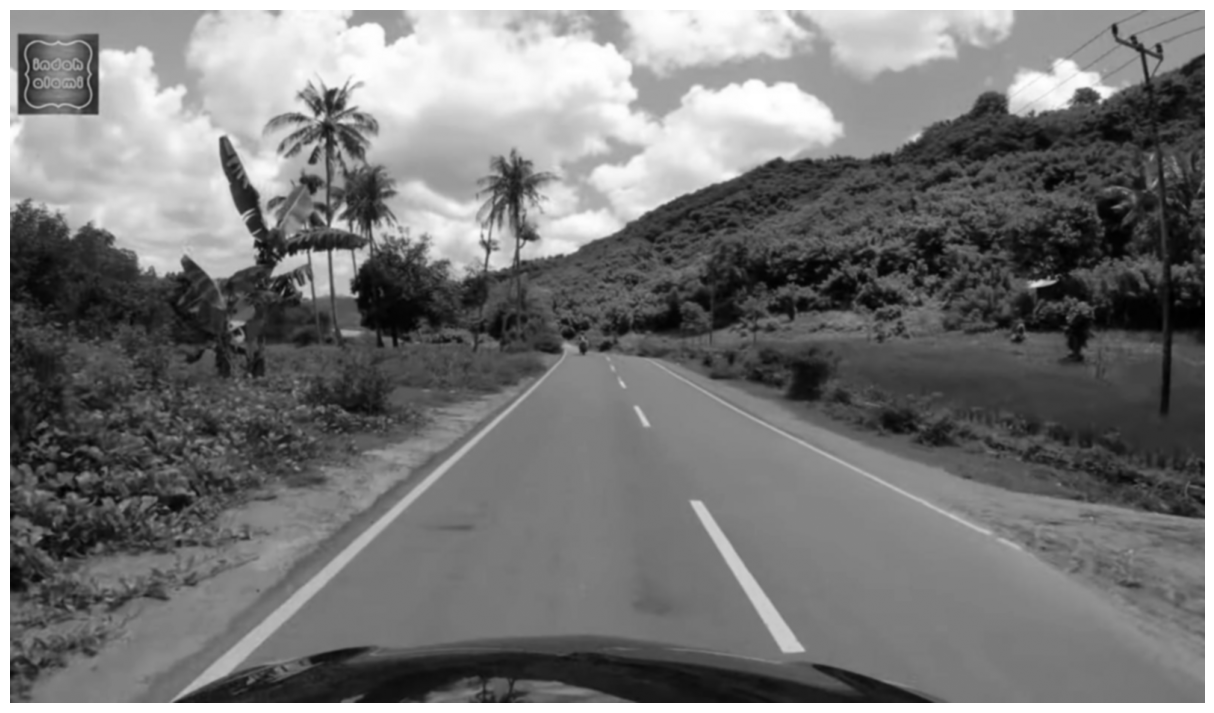

In [11]:
blur = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

plt.figure(figsize=(16, 9))
plt.imshow(blur, cmap="gray")
plt.axis("off")
plt.show()

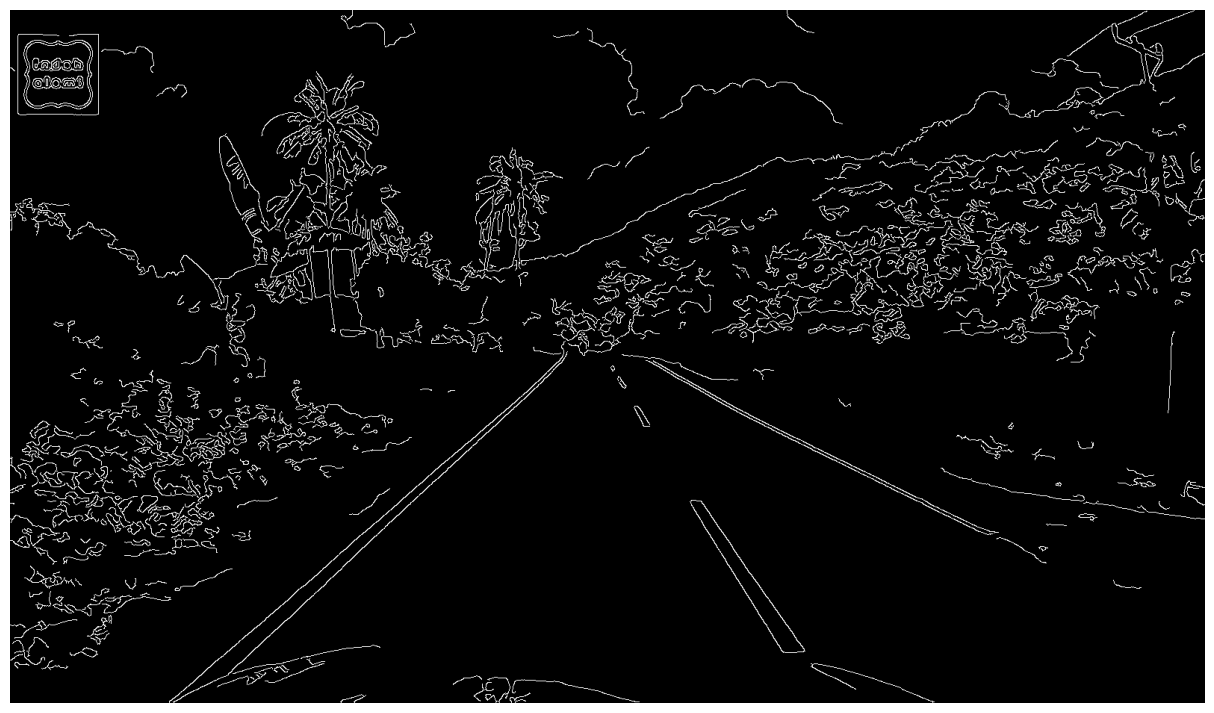

In [12]:
edges = cv2.Canny(
    blur,
    50,
    150
)

plt.figure(figsize=(16, 9))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

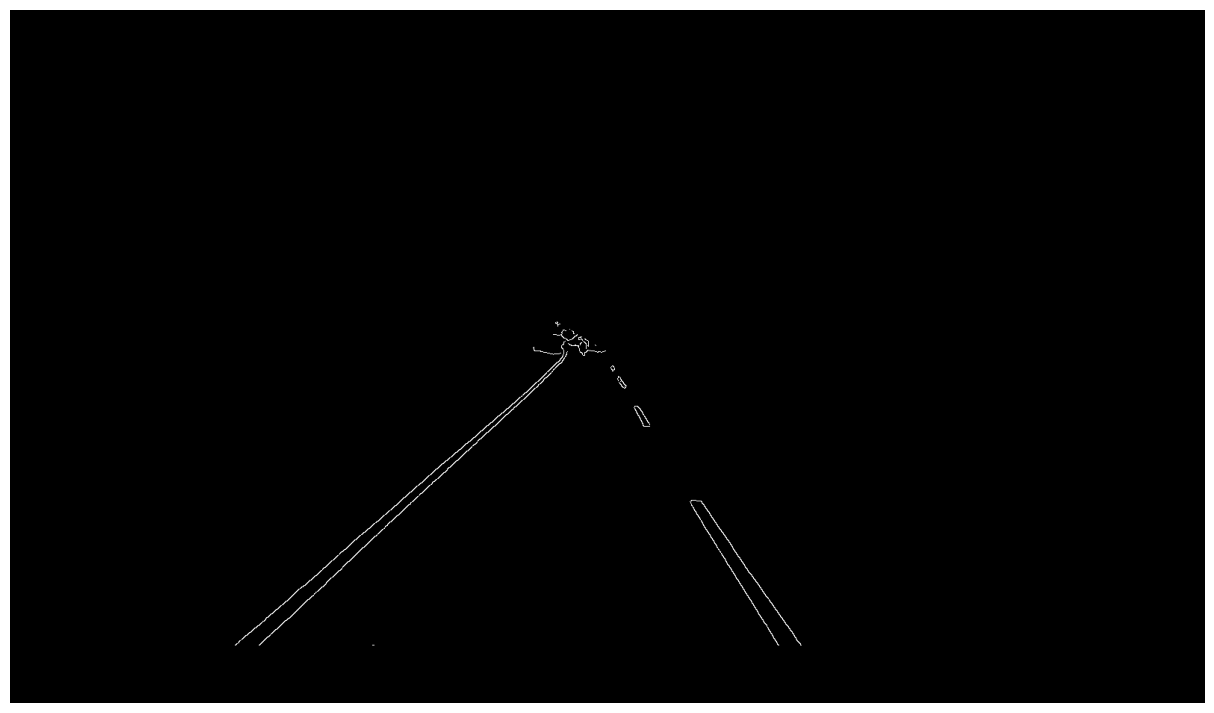

In [65]:
height, width = edges.shape

mask = np.zeros_like(edges)

polygon = np.array([[
    (300, 850),        # kiri bawah
    (1450, 850),      # batas kanan bawah
    (720, 410),         # batas kanan atas
    (650, 510)          # batas kiri atas
]], np.int32)

cv2.fillPoly(mask, polygon, 255)

roi = cv2.bitwise_and(edges, mask)

plt.figure(figsize=(16, 9))
plt.imshow(roi, cmap="gray")
plt.axis("off")
plt.show()

In [66]:
lines = cv2.HoughLinesP(
    roi,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=80,
    maxLineGap=120
)

if lines is None:
    print("❌ Tidak ada garis yang terdeteksi")
else:
    print("✅ Jumlah garis terdeteksi:", len(lines))

✅ Jumlah garis terdeteksi: 10


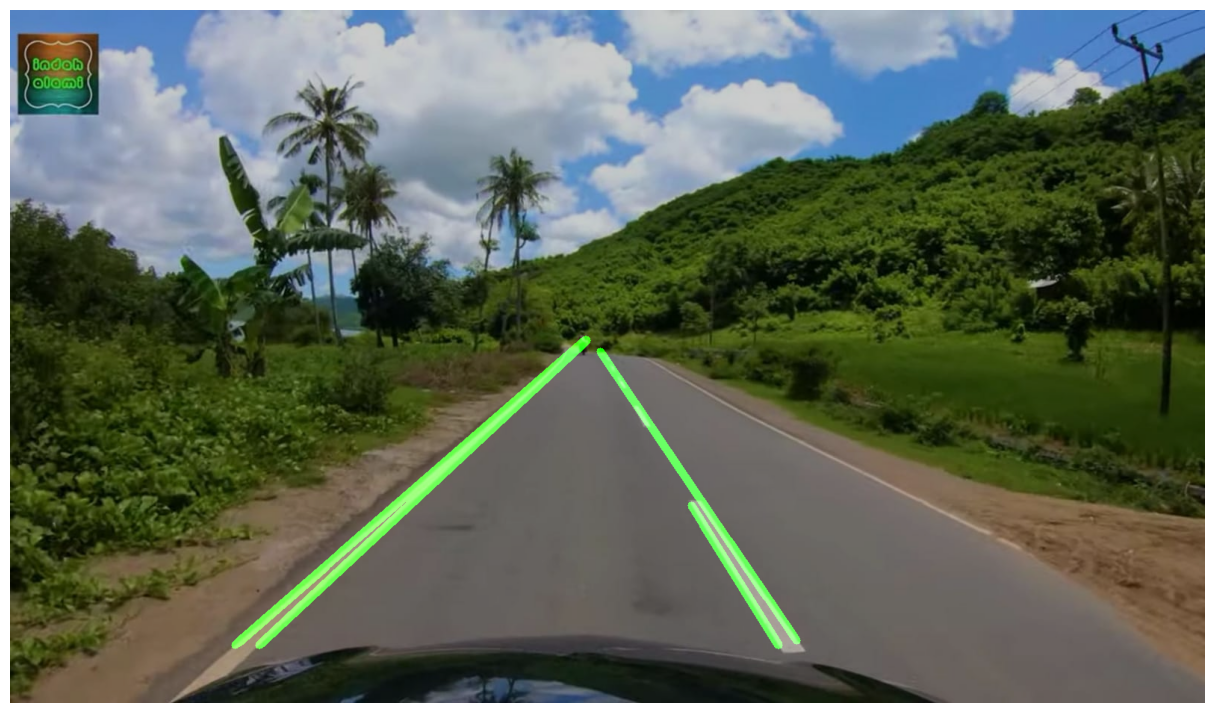

In [68]:
line_image = np.zeros_like(image)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line
        cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 10)

result = cv2.addWeighted(
    image,
    0.8,
    line_image,
    1,
    0
)

result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 9))
plt.imshow(result_rgb)
plt.axis("off")
plt.show()